#**Challenge Telecom X parte 2**

# 📌 Extracción y limpieza
## Para este análisis utilizamos la base de datos del challenge anterior, la cual fue previamente depurada mediante un proceso de limpieza de errores, duplicados y valores nulos. En el repositorio, esta base se encuentra como `d_telecom`.

In [114]:
import pandas as pd

In [80]:
datos = pd.read_csv('/content/d_telecom.csv')
datos.head()

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


#Informacion de la base de datos de Telecom X

In [81]:
datos.info()
datos.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7032 non-null   object 
 1   churn              7032 non-null   int64  
 2   gender             7032 non-null   object 
 3   senior_citizen     7032 non-null   int64  
 4   partner            7032 non-null   int64  
 5   dependents         7032 non-null   int64  
 6   tenure             7032 non-null   int64  
 7   phone_service      7032 non-null   int64  
 8   multiple_lines     7032 non-null   object 
 9   internet_service   7032 non-null   object 
 10  online_security    7032 non-null   object 
 11  online_backup      7032 non-null   object 
 12  device_protection  7032 non-null   object 
 13  tech_support       7032 non-null   object 
 14  streaming_tv       7032 non-null   object 
 15  streaming_movies   7032 non-null   object 
 16  contract           7032 

,churn,senior_citizen,partner,dependents,tenure,phone_service,paperless_billing,monthly_charges,total_charges,cuentas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159891
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002955
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.187500
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.992500
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


#Eliminación de Columnas Irrelevantes

In [82]:
datos = datos.drop(columns=["customer_id"])

#Encoding

In [83]:
X = datos.drop('churn',axis = 1)
y = datos['churn']

In [84]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [85]:
datos.columns

Index(['churn', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges',
       'cuentas_diarias'],
      dtype='object')

In [86]:
columnas =X.columns
columnas

Index(['gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges',
       'cuentas_diarias'],
      dtype='object')

In [87]:
one_hot = make_column_transformer((OneHotEncoder(drop='if_binary'),['gender', 'senior_citizen', 'partner', 'dependents',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method']),remainder = 'passthrough',sparse_threshold=0,force_int_remainder_cols=False)

In [88]:
X = one_hot.fit_transform(X)

In [89]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__gender_Male', 'onehotencoder__senior_citizen_1',
       'onehotencoder__partner_1', 'onehotencoder__dependents_1',
       'onehotencoder__phone_service_1',
       'onehotencoder__multiple_lines_No',
       'onehotencoder__multiple_lines_No phone service',
       'onehotencoder__multiple_lines_Yes',
       'onehotencoder__internet_service_DSL',
       'onehotencoder__internet_service_Fiber optic',
       'onehotencoder__internet_service_No',
       'onehotencoder__online_security_No',
       'onehotencoder__online_security_No internet service',
       'onehotencoder__online_security_Yes',
       'onehotencoder__online_backup_No',
       'onehotencoder__online_backup_No internet service',
       'onehotencoder__online_backup_Yes',
       'onehotencoder__device_protection_No',
       'onehotencoder__device_protection_No internet service',
       'onehotencoder__device_protection_Yes',
       'onehotencoder__tech_support_No',
       'onehotencoder__tech_support_No in

In [90]:
pd.DataFrame(X, columns=one_hot.get_feature_names_out(columnas))

,onehotencoder__gender_Male,onehotencoder__senior_citizen_1,onehotencoder__partner_1,onehotencoder__dependents_1,onehotencoder__phone_service_1,onehotencoder__multiple_lines_No,onehotencoder__multiple_lines_No phone service,onehotencoder__multiple_lines_Yes,onehotencoder__internet_service_DSL,onehotencoder__internet_service_Fiber optic,...,onehotencoder__contract_Two year,onehotencoder__paperless_billing_1,onehotencoder__payment_method_Bank transfer (automatic),onehotencoder__payment_method_Credit card (automatic),onehotencoder__payment_method_Electronic check,onehotencoder__payment_method_Mailed check,remainder__tenure,remainder__monthly_charges,remainder__total_charges,remainder__cuentas_diarias
0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,9.0,65.60,593.30,2.19
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,9.0,59.90,542.40,2.00
2,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,4.0,73.90,280.85,2.46
3,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,13.0,98.00,1237.85,3.27
4,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,3.0,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,13.0,55.15,742.90,1.84
7028,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,22.0,85.10,1873.70,2.84
7029,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,2.0,50.30,92.75,1.68
7030,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,67.0,67.85,4627.65,2.26


In [91]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

#Verificación de la Proporción de Cancelación (Churn)

####Verificamos si la proporcion de nuestra variable de resultado o de estudio tiene proporciones adecuadas

In [92]:
datos['churn'].value_counts()

,count
churn,
0,5163
1,1869


In [93]:
datos['churn'].value_counts(normalize=True).round(2)

,proportion
churn,
0,0.73
1,0.27


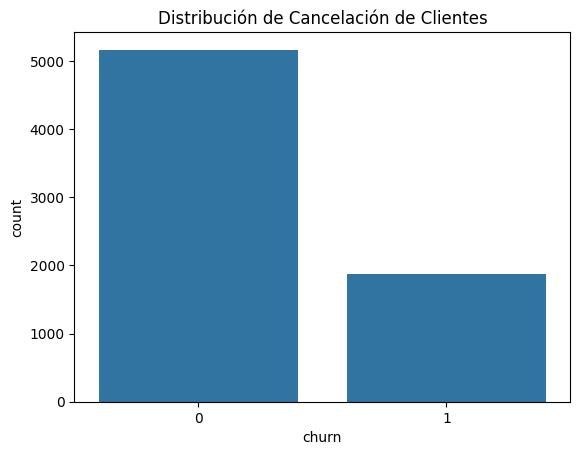

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="churn", data=datos)
plt.title("Distribución de Cancelación de Clientes")
plt.show()

#**Balanceo de Clases**

###Tras aplicar la técnica SMOTE, la distribución de la variable objetivo quedó balanceada entre ambas clases. En particular, cada categoría pasó a representar el 50% del total de observaciones, con 5163 registros por clase

In [95]:
from imblearn.over_sampling import SMOTE
oversampling = SMOTE()
X_balanceada, y_balanceada,  = oversampling.fit_resample(X,y)


In [96]:
pd.Series(y_balanceada).value_counts(normalize=True)

,proportion
0,0.5
1,0.5


In [97]:
pd.Series(y_balanceada).value_counts()

,count
0,5163
1,5163


In [98]:
from imblearn.under_sampling import NearMiss
undersample = NearMiss(version =3 )
X_balanceada,y_balanceada = undersample.fit_resample(X,y)

#**Normalización o Estandarización**

###Se evaluó la necesidad de escalar las variables explicativas de acuerdo con los modelos a implementar. Debido a que algoritmos como Regresión Logística, KNN y SVM son sensibles a la escala de los datos, se aplicó una normalización con `MinMaxScaler()`

In [99]:
from sklearn.preprocessing import MinMaxScaler
normalizacion = MinMaxScaler()
X_balanceada_normalizada = normalizacion.fit_transform(X_balanceada)

In [100]:
pd.DataFrame(X_balanceada_normalizada).head()

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.000000,0.998575,1.000000
1,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.987494,0.998304,0.987988
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.981991,0.989568,0.981982
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.918459,0.916616,0.918919
4,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.915458,0.917159,0.915916


#**Análisis de Correlación**

In [101]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   churn              7032 non-null   int64  
 1   gender             7032 non-null   object 
 2   senior_citizen     7032 non-null   int64  
 3   partner            7032 non-null   int64  
 4   dependents         7032 non-null   int64  
 5   tenure             7032 non-null   int64  
 6   phone_service      7032 non-null   int64  
 7   multiple_lines     7032 non-null   object 
 8   internet_service   7032 non-null   object 
 9   online_security    7032 non-null   object 
 10  online_backup      7032 non-null   object 
 11  device_protection  7032 non-null   object 
 12  tech_support       7032 non-null   object 
 13  streaming_tv       7032 non-null   object 
 14  streaming_movies   7032 non-null   object 
 15  contract           7032 non-null   object 
 16  paperless_billing  7032 

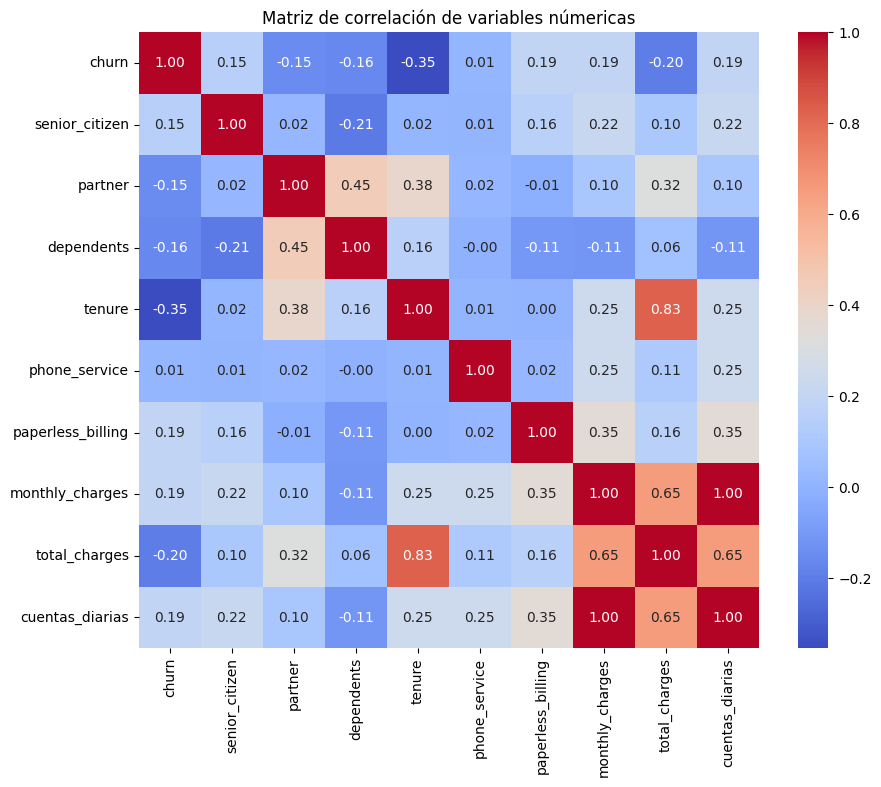

In [102]:
datos_numericos = datos.select_dtypes(include=['int64', 'float64'])

corr_matrix = datos_numericos.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación de variables númericas')
plt.show()

In [103]:
corr_churn = corr_matrix['churn'].sort_values(ascending=False)
print(corr_churn)

churn                1.000000
cuentas_diarias      0.192914
monthly_charges      0.192858
paperless_billing    0.191454
senior_citizen       0.150541
phone_service        0.011691
partner             -0.149982
dependents          -0.163128
total_charges       -0.199484
tenure              -0.354049
Name: churn, dtype: float64


In [104]:
datos.columns

Index(['churn', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure',
       'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges',
       'cuentas_diarias'],
      dtype='object')

#**Análisis Dirigido**

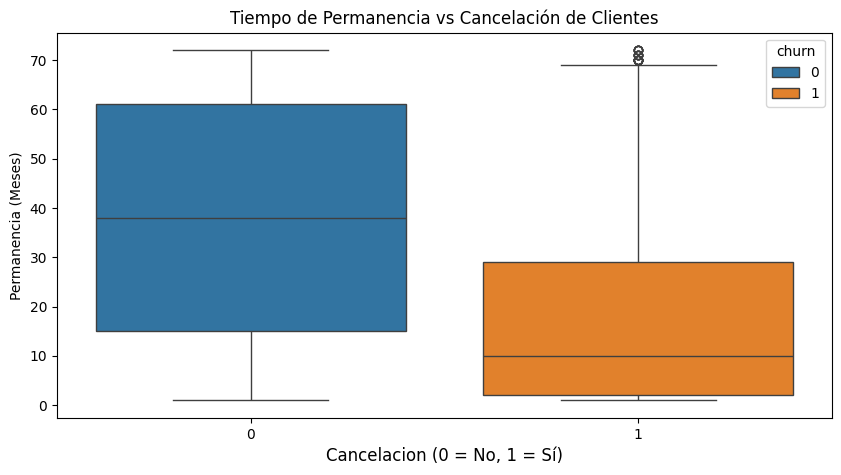

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x="churn", y="tenure", data=datos,hue='churn')
plt.title("Tiempo de Permanencia vs Cancelación de Clientes")
plt.xlabel("Cancelacion")
plt.xlabel('Cancelacion (0 = No, 1 = Sí)', fontsize=12)

plt.ylabel("Permanencia (Meses)")

plt.show()

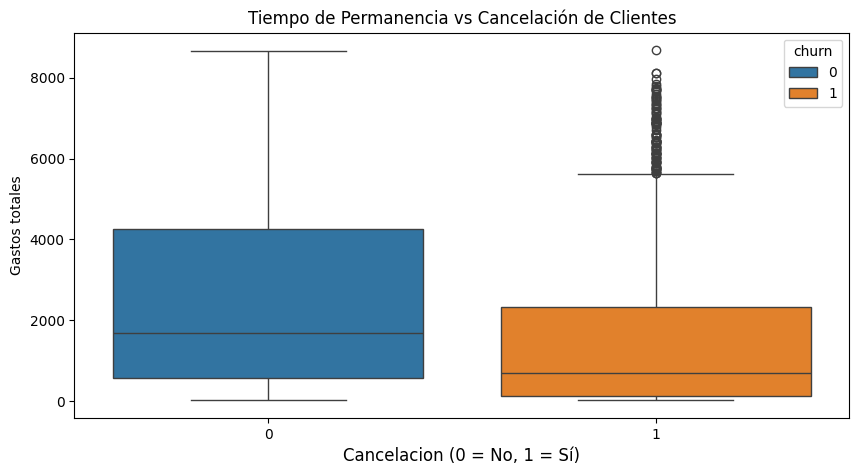

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x="churn", y="total_charges", data=datos,hue='churn')
plt.title("Tiempo de Permanencia vs Cancelación de Clientes")
plt.xlabel("Cancelacion")
plt.xlabel('Cancelacion (0 = No, 1 = Sí)', fontsize=12)

plt.ylabel("Gastos totales")

plt.show()

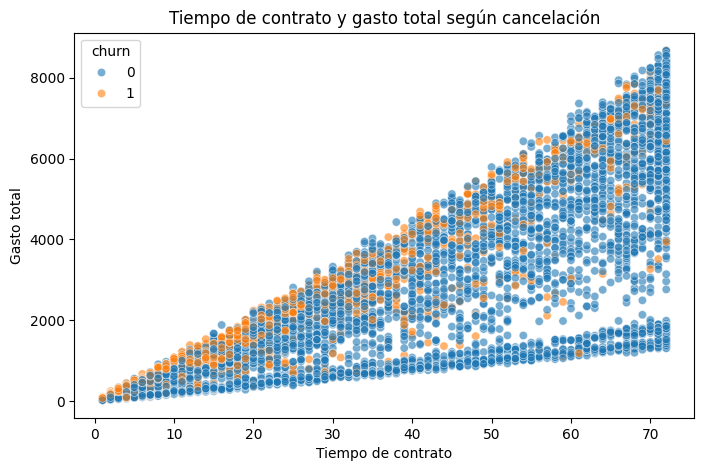

In [107]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=datos, x='tenure', y='total_charges', hue='churn', alpha=0.6)
plt.title('Tiempo de contrato y gasto total según cancelación')
plt.xlabel('Tiempo de contrato')
plt.ylabel('Gasto total')
plt.show()


#🤖Modelado Predictivo

#Separación de Datos

In [108]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


#Creación y evaluación de Modelos

##-Modelo Regresión Logistica

In [109]:
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Normalización
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

# Balanceo solo en entrenamiento
smote = SMOTE(random_state=42)
X_train_norm_bal, y_train_bal = smote.fit_resample(X_train_norm, y_train)

# Modelo
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_norm_bal, y_train_bal)

# Predicción
y_pred_log = log_model.predict(X_test_norm)

# Evaluación
print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Accuracy Regresión Logística: 0.7476901208244492
[[752 281]
 [ 74 300]]
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.77      0.72      1407
weighted avg       0.81      0.75      0.76      1407



##-Random forest

In [110]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Balanceo solo en entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal_rf = smote.fit_resample(X_train, y_train)

# Modelo
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_bal, y_train_bal_rf)

# Predicción
y_pred_rf = rf_model.predict(X_test)

# Evaluación
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy Random Forest: 0.7860696517412935
[[913 120]
 [181 193]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [111]:
# Score en entrenamiento y prueba
train_log = log_model.score(X_train_norm_bal, y_train_bal)
test_log = log_model.score(X_test_norm, y_test)

train_rf = rf_model.score(X_train_bal, y_train_bal_rf)
test_rf = rf_model.score(X_test, y_test)

print("Regresión Logística - Train:", train_log, "Test:", test_log)
print("Random Forest - Train:", train_rf, "Test:", test_rf)


Regresión Logística - Train: 0.7784503631961259 Test: 0.7476901208244492
Random Forest - Train: 0.9983050847457627 Test: 0.7860696517412935


##Los resultados muestran que Random Forest alcanzó una mayor exactitud general (0.7861) en comparación con la Regresión Logística (0.7477). Sin embargo, al analizar la cancelacion, la Regresión Logística presentó un mejor recall para la clase 1 (0.80), frente a 0.52 en Random Forest, lo que indica un mejor desempeño para identificar clientes que efectivamente cancelan el servicio.

##En términos de ajuste, la Regresión Logística mostró un comportamiento más estable entre entrenamiento y prueba, lo que sugiere una adecuada capacidad de generalización. En cambio, Random Forest presentó una diferencia considerable entre el desempeño en entrenamiento (0.9983) y prueba (0.7861), evidenciando signos de overfitting.

##Por tanto, si el objetivo principal es maximizar la detección de clientes con riesgo de cancelación, la Regresión Logística resulta más conveniente. Si se busca mayor exactitud global, Random Forest ofrece mejores resultados


#Análisis de la Importancia de las Variables

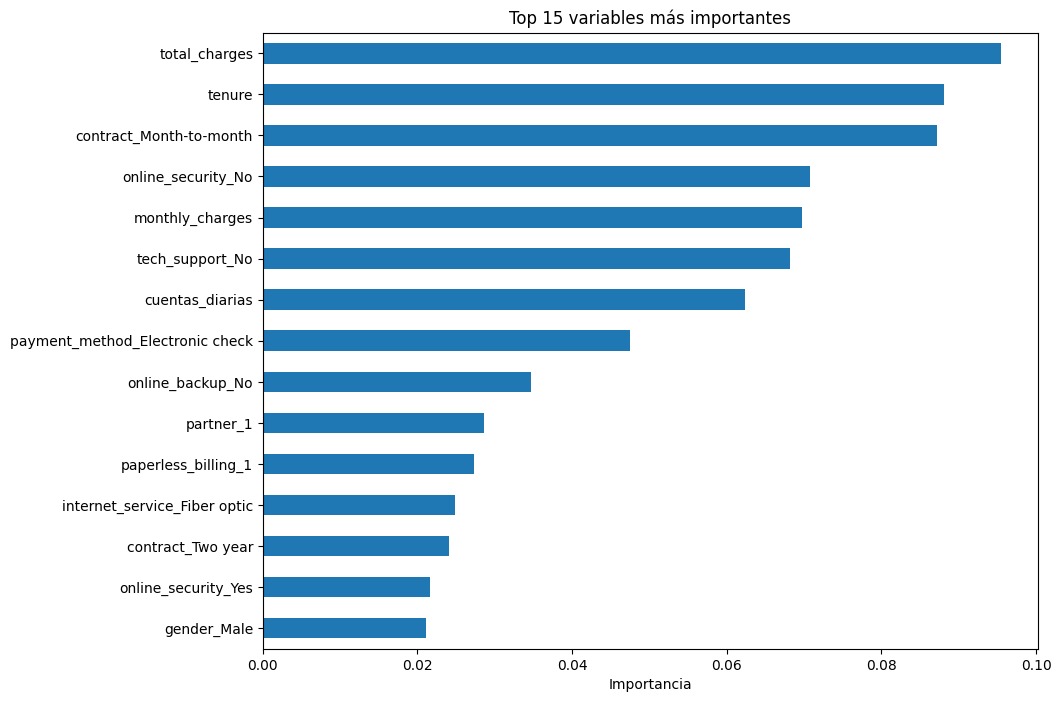

In [118]:
feature_names = one_hot.get_feature_names_out(datos.drop('churn', axis=1).columns)

feature_names_limpios = [
    col.replace('onehotencoder__', '').replace('remainder__', '')
    for col in feature_names
]

importances = rf_model.feature_importances_
features = pd.Series(importances, index=feature_names_limpios)

features.sort_values(ascending=False).head(15).sort_values().plot(kind="barh", figsize=(10,8))
plt.title("Top 15 variables más importantes")
plt.xlabel("Importancia")
plt.show()


#Conclusiones

#El análisis muestra que factores como los gasto totales, los meses de permanencia del cliente y el tipo de contrato(contrato month-to month) influyen significativamente en la decision del cliente de cancelar o no los servicios de Telecom

#El modelo Random Forest presentó un desempeño superior en la predicción de cancelacion, mostrando mejor capacidad para capturar patrones complejos en los datos.